# H3 — Feature Importance 기반 주차 후보 Rule (RandomForest 단독)

**H3 가설:** H1 후보군은 H1에서 사용하지 않은 관측 피처를 활용해 설명 가능한 단순 rule로 근사할 수 있을 것이다.

H1의 성장 정체 후보 cluster(`is_stagnant_cluster`, **380명**, 6mo·4피처·k=4)를 **H1 채택축과 다른 관측 피처**
(raw state + 비-H1 delta)로 근사하고, permutation importance로 단순·설명가능 rule을 도출한 뒤 접속 게이트를 결합한다.

**설계 고정**
- 모델: `RandomForestClassifier` **단독** (Boosting/XGBoost 미사용)
- target: `is_stagnant_cluster` (380, 6mo) **단일** — 과거 현재성 라벨(52/39)·`h1_current_candidates.csv`는 폐기(temporal_external_validation 삭제)
- 피처: H1이 쓴 **4 delta 채택축**(slog Δcp·Δhexa·log Δunion·log Δauth)과 다른 raw state + 비-H1 delta(cumexp)
- 누수 가드(확장): 각 후보 피처 vs **H1 네 축**(recent6 기준 slog Δcp·Δhexa·log Δunion·log Δauth) `|corr|>0.85` → drop
- RF 단조불변 주의: 같은 변수 raw+log 동시투입 금지 → 변수당 한 형태
- 최종 rule = `stagnant_growth_rule AND access_active_months >= 2`

**해석 주의**: 확정 주차 ground truth 없음 → 모든 지표는 H1 파생 라벨 대비 성능. 실제 주차 검증 성능으로 해석 금지.


## 1. Setup — imports · 폰트 · 상수 · 헬퍼

In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = "../assets/NanumSquareNeo-bRg.ttf"
font_manager.fontManager.addfont(_font_path)
matplotlib.rcParams["font.family"] = font_manager.FontProperties(fname=_font_path).get_name()
matplotlib.rcParams["axes.unicode_minus"] = False

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)

RANDOM_STATE = 42
UPPER_CLIP_Q = 0.99
CP_WINSOR_Q  = (0.01, 0.99)

def qclip_nonnegative(s, upper_q=UPPER_CLIP_Q):
    s = pd.to_numeric(s, errors="coerce").clip(lower=0)
    return s.clip(upper=s.quantile(upper_q))

def winsor_quantile(s, lower_q=CP_WINSOR_Q[0], upper_q=CP_WINSOR_Q[1]):
    s = pd.to_numeric(s, errors="coerce")
    lo, hi = s.quantile([lower_q, upper_q])
    return s.clip(lower=lo, upper=hi)

def slog(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.sign(x) * np.log1p(np.abs(x))

print("setup ok")


setup ok


## 2. 데이터 로드 — features + 라벨(cluster 380) + raw snapshots

- `cluster_labels.csv` = H1 6mo·4피처·k=4 → `is_stagnant_cluster` **380명**(단일 target).
- 현재성 라벨(52/39)·`h1_current_candidates.csv`는 삭제됨 → **미사용**.


In [2]:
df_feat = pd.read_csv("../data/features_monthly.csv", encoding="utf-8-sig")
lab      = pd.read_csv("../data/cluster_labels.csv", encoding="utf-8-sig")        # is_stagnant_cluster (380, 6mo)
snap     = pd.read_csv("../data/monthly_snapshots_raw.csv", encoding="utf-8-sig") # raw combat_power per month

df = df_feat.merge(lab[["ocid", "cluster_km", "is_stagnant_cluster"]], on="ocid", how="left")

# H1 analysis clip: level 270-290 + has cluster label
df = df[df["level"].between(270, 290)].copy()
df = df.dropna(subset=["is_stagnant_cluster"]).reset_index(drop=True)
df["is_stagnant_cluster"] = df["is_stagnant_cluster"].astype(int)

print(f"rows: {len(df):,}")
print(f"positive(is_stagnant_cluster): {int(df['is_stagnant_cluster'].sum())} "
      f"({df['is_stagnant_cluster'].mean():.1%})")


rows: 2,000
positive(is_stagnant_cluster): 380 (19.0%)


## 3. `combat_power_latest` 파생

`features_monthly.csv`엔 raw 전투력이 없고 **delta만** 있음 → `monthly_snapshots_raw.csv`에서
ocid별 **마지막 유효월**(combat_power>0)의 전투력을 추출해 머지. raw state 피처로 사용
(레벨 270+ 표본은 약 50M~350M 스케일).


In [3]:
s = snap.copy()
s["combat_power"] = pd.to_numeric(s["combat_power"], errors="coerce")
s = s[s["combat_power"] > 0].sort_values(["ocid", "year_month"])
cp_latest = (s.groupby("ocid")["combat_power"].last()
               .rename("combat_power_latest").reset_index())
df = df.merge(cp_latest, on="ocid", how="left")
print(f"combat_power_latest missing: {df['combat_power_latest'].isna().sum()}")
print((df["combat_power_latest"] / 1e6).describe().round(1))


combat_power_latest missing: 0
count    2000.0
mean      125.6
std        68.8
min        50.0
25%        75.9
50%       105.4
75%       153.7
max       605.3
Name: combat_power_latest, dtype: float64


## 4. 전처리 + 피처 풀 조립

- **Tier A (raw state, H3 입력)**: level · union_level · authentic_symbol_score · hexa_level_sum · log_exp · character_age_months · combat_power_latest(winsor)
- **Tier B (비-H1 delta)**: cumexp(log) avg + recent3/6 — **union·auth·cp·hexa delta는 제외**(H1 4 채택축)
- **Tier C (access, importance용)**: access_active_months · access_ratio · access_recent
- **제외(누수)**: Δ{combat_power(+slog)·hexa·union_level·authentic_symbol} 전부 + 각 recent3/6 · hexa_fragments · (경계)Δlevel
- RF 단조불변 → 변수당 한 형태만(cumexp는 log형만 채택)


In [4]:
df["union_level"] = df["union_level"].fillna(0)
df["combat_power_latest"] = winsor_quantile(df["combat_power_latest"])
df["combat_power_latest"] = df["combat_power_latest"].fillna(df["combat_power_latest"].median())

TIER_A = ["level", "union_level", "authentic_symbol_score", "hexa_level_sum",
          "log_exp", "character_age_months", "combat_power_latest"]
TIER_B = ["log1p_avg_monthly_delta_cumexp",
          "log1p_recent3_delta_cumexp", "log1p_recent6_delta_cumexp"]
TIER_C = ["access_active_months", "access_ratio", "access_recent"]

CANDIDATE_FEATURES = TIER_A + TIER_B + TIER_C
for c in CANDIDATE_FEATURES:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

y = df["is_stagnant_cluster"].values
print(f"candidate features {len(CANDIDATE_FEATURES)}:")
for t, name in [(TIER_A, "A raw"), (TIER_B, "B delta"), (TIER_C, "C access")]:
    print(f"  [{name}] {t}")


candidate features 13:
  [A raw] ['level', 'union_level', 'authentic_symbol_score', 'hexa_level_sum', 'log_exp', 'character_age_months', 'combat_power_latest']
  [B delta] ['log1p_avg_monthly_delta_cumexp', 'log1p_recent3_delta_cumexp', 'log1p_recent6_delta_cumexp']
  [C access] ['access_active_months', 'access_ratio', 'access_recent']


## 5. 누수 가드(확장) — H1 **네 축**과 `|corr|>0.85` 피처 drop

H1은 6mo로 override되므로 네 축을 **recent6 delta** 기준으로 inline 재계산:
`cp_slog=slog(winsor(Δcp))`, `hexa_avg=qclip(Δhexa)`, `union_log=log1p(qclip(Δunion))`, `auth_log=log1p(qclip(Δauth))`.
각 후보 피처의 네 축 대비 최대 절대상관이 0.85 초과면 H1 경계 직접 복제로 보고 제외.


In [5]:
LEAK_THRESH = 0.85
h1_axes = {
    "cp_slog":   slog(winsor_quantile(df["recent6_delta_combat_power"])),
    "hexa_avg":  qclip_nonnegative(df["recent6_delta_hexa"]),
    "union_log": np.log1p(qclip_nonnegative(df["recent6_delta_union_level"])),
    "auth_log":  np.log1p(qclip_nonnegative(df["recent6_delta_authentic_symbol"])),
}

rows = []
for c in CANDIDATE_FEATURES:
    rec = {"feature": c}
    mx = 0.0
    for an, av in h1_axes.items():
        r = np.corrcoef(df[c], av)[0, 1]
        rec[f"corr_{an}"] = r
        mx = max(mx, abs(r))
    rec["max_abs"] = mx
    rows.append(rec)
leak = pd.DataFrame(rows).sort_values("max_abs", ascending=False).reset_index(drop=True)
dropped  = leak.loc[leak["max_abs"] > LEAK_THRESH, "feature"].tolist()
FEATURES = [c for c in CANDIDATE_FEATURES if c not in dropped]

print(f"leakage drop(|corr|>{LEAK_THRESH}): {dropped if dropped else 'none'}")
print(f"final features {len(FEATURES)}")
display(leak.round(3))

X = df[FEATURES].values


leakage drop(|corr|>0.85): none
final features 13


,feature,corr_cp_slog,corr_hexa_avg,corr_union_log,corr_auth_log,max_abs
0,hexa_level_sum,0.053,0.535,0.108,0.088,0.535
1,combat_power_latest,0.302,0.534,0.165,0.218,0.534
2,level,0.164,0.506,0.283,0.290,0.506
3,log1p_avg_monthly_delta_cumexp,0.247,0.471,0.390,0.436,0.471
4,authentic_symbol_score,0.084,0.447,0.150,0.250,0.447
5,log1p_recent6_delta_cumexp,0.298,0.407,0.384,0.409,0.409
6,log1p_recent3_delta_cumexp,0.325,0.304,0.367,0.319,0.367
7,access_ratio,0.248,0.329,0.293,0.234,0.329
8,access_recent,0.210,0.164,0.257,0.162,0.257
9,log_exp,0.029,0.240,0.066,0.109,0.240


## 6. RandomForestClassifier + 5-fold StratifiedKFold CV

In [6]:
rf = RandomForestClassifier(n_estimators=400, class_weight="balanced",
                            random_state=RANDOM_STATE, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
proba = cross_val_predict(rf, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("-- 5-fold CV (out-of-fold) --")
print(f"ROC-AUC : {roc_auc_score(y, proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y, proba):.4f}")
print(f"F1      : {f1_score(y, pred):.4f}")
print(f"Recall  : {recall_score(y, pred):.4f}   Precision: {precision_score(y, pred):.4f}")

rf.fit(X, y)   # full fit for importance / rule extraction


-- 5-fold CV (out-of-fold) --
ROC-AUC : 0.8495
PR-AUC  : 0.5365
F1      : 0.4029
Recall  : 0.2921   Precision: 0.6491


RandomForestClassifier(class_weight='balanced', n_estimators=400, n_jobs=-1,
                       random_state=42)

## 6.5 ROC · PR 곡선 (headline AUC 시각화)

5-fold out-of-fold 예측(`proba`)으로 ROC·정밀도-재현율 곡선을 그린다. 보고된 ROC-AUC 0.85는 텍스트로만 인용되던 핵심 수치 → 곡선으로 시각화. 양성 19% 불균형이라 PR 곡선(기저율 0.19 대비 AP)도 함께 본다. `figures/h3_roc_pr.png`.

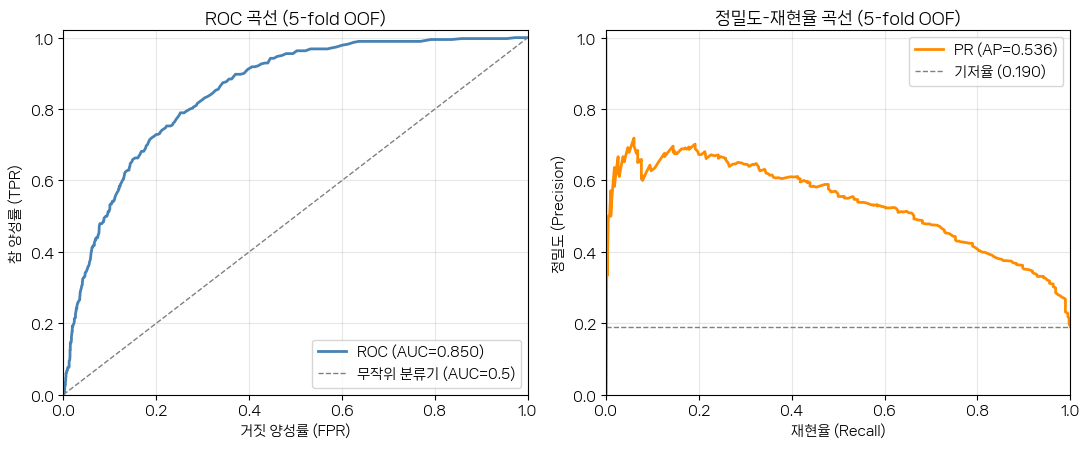

ROC-AUC=0.8495  PR-AUC=0.5365  base_rate=0.1900


In [7]:
from sklearn.metrics import roc_curve, precision_recall_curve

# 5-fold OOF 예측(proba) 기반 ROC · PR 곡선 — headline AUC 시각화
roc_fpr, roc_tpr, _ = roc_curve(y, proba)
pr_prec, pr_rec, _  = precision_recall_curve(y, proba)
auc_roc   = roc_auc_score(y, proba)
auc_pr    = average_precision_score(y, proba)
base_rate = float(np.mean(y))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

ax = axes[0]
ax.plot(roc_fpr, roc_tpr, color="steelblue", lw=2, label=f"ROC (AUC={auc_roc:.3f})")
ax.plot([0, 1], [0, 1], ls="--", c="gray", lw=1, label="무작위 분류기 (AUC=0.5)")
ax.set_xlabel("거짓 양성률 (FPR)"); ax.set_ylabel("참 양성률 (TPR)")
ax.set_title("ROC 곡선 (5-fold OOF)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

ax = axes[1]
ax.plot(pr_rec, pr_prec, color="darkorange", lw=2, label=f"PR (AP={auc_pr:.3f})")
ax.axhline(base_rate, ls="--", c="gray", lw=1, label=f"기저율 ({base_rate:.3f})")
ax.set_xlabel("재현율 (Recall)"); ax.set_ylabel("정밀도 (Precision)")
ax.set_title("정밀도-재현율 곡선 (5-fold OOF)")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

fig.tight_layout(); fig.savefig("figures/h3_roc_pr.png", dpi=120); plt.show()
print(f"ROC-AUC={auc_roc:.4f}  PR-AUC={auc_pr:.4f}  base_rate={base_rate:.4f}")

## 7. Feature Importance — permutation(주) + impurity(교차)

,feature,perm,perm_std,impurity
0,log1p_recent3_delta_cumexp,0.1079,0.0040,0.1596
1,combat_power_latest,0.1019,0.0044,0.1680
2,log1p_recent6_delta_cumexp,0.0976,0.0024,0.1247
3,access_ratio,0.0576,0.0040,0.0570
4,hexa_level_sum,0.0335,0.0027,0.0808
5,log_exp,0.0262,0.0022,0.0727
6,log1p_avg_monthly_delta_cumexp,0.0218,0.0022,0.0789
7,level,0.0210,0.0026,0.0501
8,union_level,0.0196,0.0024,0.0688
9,authentic_symbol_score,0.0154,0.0020,0.0590


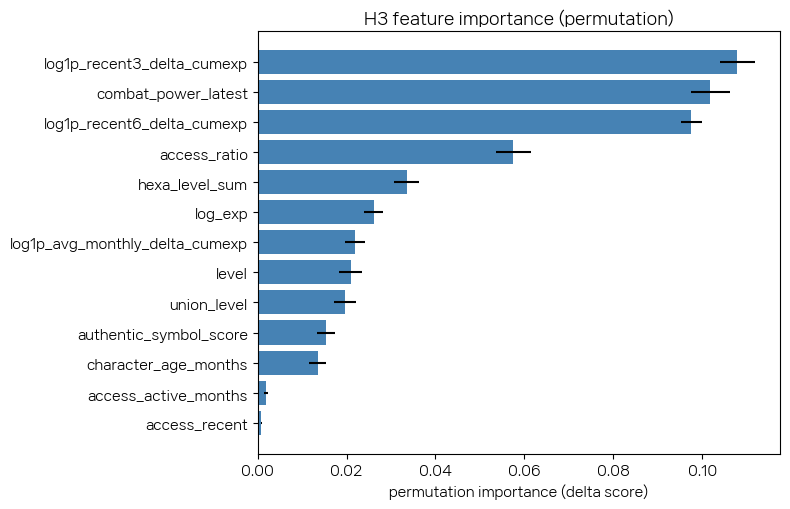

top 3: ['log1p_recent3_delta_cumexp', 'combat_power_latest', 'log1p_recent6_delta_cumexp']


In [8]:
perm = permutation_importance(rf, X, y, n_repeats=20,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.DataFrame({"feature": FEATURES,
                     "perm": perm.importances_mean,
                     "perm_std": perm.importances_std,
                     "impurity": rf.feature_importances_})
       .sort_values("perm", ascending=False).reset_index(drop=True))
display(imp.round(4))

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(FEATURES))))
d = imp.iloc[::-1]
ax.barh(d["feature"], d["perm"], xerr=d["perm_std"], color="steelblue")
ax.set_xlabel("permutation importance (delta score)")
ax.set_title("H3 feature importance (permutation)")
fig.tight_layout(); fig.savefig("figures/h3_importance.png", dpi=120); plt.show()

TOP_FEATURES = imp["feature"].head(3).tolist()
print("top 3:", TOP_FEATURES)


## 8. Rule 추출 — 상위 피처로 얇은 DecisionTree(max_depth=2)

RF=중요도 산출용, **얇은 트리=사람이 읽는 명시 임계값 rule**. 상위 2피처(`log1p_recent3_delta_cumexp`,
`combat_power_latest` — 둘 다 값이 낮을수록 정체)로 depth-2 트리를 뽑아 `export_text`로 규칙 추출.


-- extracted rule (export_text) --
|--- log1p_recent3_delta_cumexp <= 30.84
|   |--- combat_power_latest <= 127748420.00
|   |   |--- class: 1
|   |--- combat_power_latest >  127748420.00
|   |   |--- class: 0
|--- log1p_recent3_delta_cumexp >  30.84
|   |--- combat_power_latest <= 118327752.00
|   |   |--- class: 0
|   |--- combat_power_latest >  118327752.00
|   |   |--- class: 0



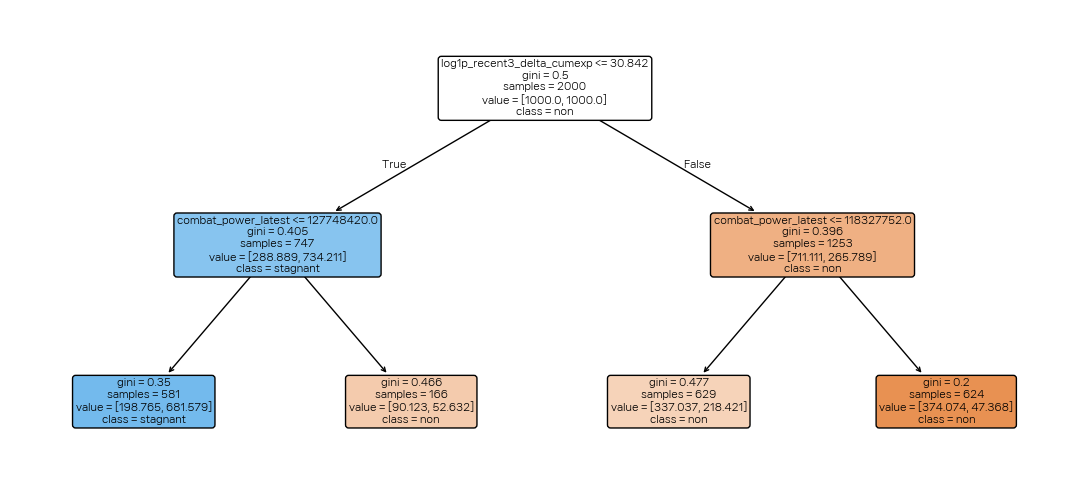


stagnant_growth_rule positive: 581


In [9]:
RULE_FEATURES = TOP_FEATURES[:2]          # top-2 for a readable rule
Xr = df[RULE_FEATURES].values
stump = DecisionTreeClassifier(max_depth=2, class_weight="balanced",
                               random_state=RANDOM_STATE)
stump.fit(Xr, y)

print("-- extracted rule (export_text) --")
print(export_text(stump, feature_names=RULE_FEATURES))

fig, ax = plt.subplots(figsize=(11, 5))
plot_tree(stump, feature_names=RULE_FEATURES, class_names=["non", "stagnant"],
          filled=True, rounded=True, ax=ax)
fig.tight_layout(); fig.savefig("figures/h3_rule_tree.png", dpi=120); plt.show()

df["stagnant_growth_rule"] = stump.predict(Xr).astype(int)
print(f"\nstagnant_growth_rule positive: {int(df['stagnant_growth_rule'].sum())}")


## 9. Threshold sweep → 운용점 선정 (목표 FPR ≤ 0.10)

loose 트리는 over-flag·FPR 높음. 상위 2피처 rule을 유지하되
`log1p_recent3_delta_cumexp <= CUM_T`(트리 임계)를 고정하고 `combat_power_latest` 임계 `T_cp`를 스윗해
**FPR(vs is_stagnant_cluster) ≤ 0.10** 운용점을 고른다. 접속 게이트(access≥2) 고정.


CUM_T (log1p recent3 cumexp) = 30.84
access_gate(>=2) pass: 2000 of 2000


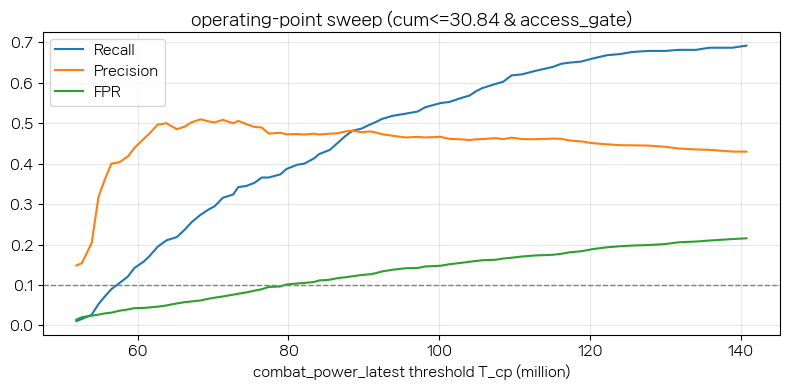

 T_cp(M)  flag   Prec    Rec    FPR
      60   128  0.453  0.153  0.043
      70   220  0.500  0.289  0.068
      80   314  0.471  0.389  0.102
      90   388  0.479  0.489  0.125
     100   447  0.468  0.550  0.147

-> adopt T_OP = 70,000,000  FPR=0.068 (target <= 0.1)


In [10]:
# CUM_T = root cum-exp threshold from the extracted tree
tree_thr = stump.tree_.threshold[stump.tree_.feature == RULE_FEATURES.index("log1p_recent3_delta_cumexp")]
CUM_T = float(tree_thr.max()) if len(tree_thr) else float(df["log1p_recent3_delta_cumexp"].quantile(0.33))
CUM_T = round(CUM_T, 2)
TARGET_FPR = 0.10

df["access_gate"] = (pd.to_numeric(df["access_active_months"], errors="coerce")
                       .fillna(0) >= 2).astype(int)
cum_cond = (df["log1p_recent3_delta_cumexp"] <= CUM_T).values
cpl      = df["combat_power_latest"].values
y_clu    = df["is_stagnant_cluster"].astype(bool).values
gate     = df["access_gate"].astype(bool).values
neg = ~y_clu; P = y_clu.sum()
print(f"CUM_T (log1p recent3 cumexp) = {CUM_T}")
print(f"access_gate(>=2) pass: {int(gate.sum())} of {len(df)}")

# (a) fine sweep -> curve
ts = np.quantile(cpl, np.linspace(0.02, 0.70, 70))
rec, prec, fpr = [], [], []
for t in ts:
    flag = cum_cond & (cpl <= t) & gate
    tp = (flag & y_clu).sum(); fp = (flag & neg).sum()
    rec.append(tp / P); prec.append(tp / max(1, flag.sum())); fpr.append(fp / neg.sum())
rec, prec, fpr = map(np.array, (rec, prec, fpr))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts/1e6, rec, label="Recall"); ax.plot(ts/1e6, prec, label="Precision")
ax.plot(ts/1e6, fpr, label="FPR"); ax.axhline(TARGET_FPR, ls="--", c="gray", lw=1)
ax.set_xlabel("combat_power_latest threshold T_cp (million)")
ax.set_title(f"operating-point sweep (cum<={CUM_T} & access_gate)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("figures/h3_threshold_sweep.png", dpi=120); plt.show()

# (b) round-threshold comparison table
print(f"{'T_cp(M)':>8} {'flag':>5} {'Prec':>6} {'Rec':>6} {'FPR':>6}")
for T in [60e6, 70e6, 80e6, 90e6, 100e6]:
    flag = cum_cond & (cpl <= T) & gate
    tp = (flag & y_clu).sum(); fp = (flag & neg).sum()
    print(f"{T/1e6:8.0f} {flag.sum():5d} {tp/max(1,flag.sum()):6.3f} {tp/P:6.3f} {fp/neg.sum():6.3f}")

# (c) adopt conservative round operating point with FPR <= target
T_OP = 70_000_000
flag_op = cum_cond & (cpl <= T_OP) & gate
print(f"\n-> adopt T_OP = {T_OP:,}  FPR={(flag_op & neg).sum()/neg.sum():.3f} (target <= {TARGET_FPR})")


## 10. 최종 운용 rule = 성장정체 rule(운용점) AND 접속 게이트

- `rule_op` (성장정체, 운용점) = `log1p_recent3_delta_cumexp <= CUM_T` AND `combat_power_latest <= T_OP`
- `final_rule` = `rule_op` AND `access_active_months >= 2`
- `access_active_months >= 2` 게이트는 표본이 이미 ≥10 접속 통제라 **전원 통과**(in-sample no-op). 공식 운용시 dormant 제외용 명시 요건.
- 대조용 `stagnant_growth_rule` = depth-2 트리(loose baseline) 유지


In [11]:
df["rule_op"]    = (cum_cond & (cpl <= T_OP)).astype(int)
df["final_rule"] = (df["rule_op"].astype(bool) & df["access_gate"].astype(bool)).astype(int)

print(f"stagnant_growth_rule (loose tree) positive : {int(df['stagnant_growth_rule'].sum())}")
print(f"rule_op (operating-point)                  : {int(df['rule_op'].sum())}")
print(f"access_gate pass                           : {int(df['access_gate'].sum())}")
print(f"final_rule (rule_op AND gate)              : {int(df['final_rule'].sum())}")


stagnant_growth_rule (loose tree) positive : 581
rule_op (operating-point)                  : 220
access_gate pass                           : 2000
final_rule (rule_op AND gate)              : 220


## 11. 평가표 — loose baseline vs 운용점 final_rule

target = `is_stagnant_cluster`(380) 단일. FPR = 비정체(정상) 오분류율. **주의: in-sample** — sweep/rule 평가는 학습에 쓴 동일 2,000명 라벨 대상(held-out 없음) → 탐지 성능 아니라 H1 라벨 근사도.

In [12]:
def metric_row(pred_col, label_col, name):
    yt = df[label_col].fillna(False).astype(bool).values
    yp = df[pred_col].astype(bool).values
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[False, True]).ravel()
    return {"rule": pred_col, "label": name, "positives": int(yt.sum()),
            "Precision": tp / max(1, tp + fp), "Recall": tp / max(1, tp + fn),
            "F1": (2*tp) / max(1, 2*tp + fp + fn), "FPR": fp / max(1, fp + tn)}

rows = []
for pc in ["stagnant_growth_rule", "final_rule"]:
    rows.append(metric_row(pc, "is_stagnant_cluster", "stagnant_cluster(380)"))
ev = pd.DataFrame(rows)[["rule", "label", "positives", "Precision", "Recall", "F1", "FPR"]]
display(ev.round(3))


,rule,label,positives,Precision,Recall,F1,FPR
0,stagnant_growth_rule,stagnant_cluster(380),380,0.446,0.682,0.539,0.199
1,final_rule,stagnant_cluster(380),380,0.500,0.289,0.367,0.068


## 12. 저장 — per-char 예측 + 평가표 + 운용점

In [13]:
out = df[["ocid", "character_name", "character_class", "level",
          "is_stagnant_cluster",
          "stagnant_growth_rule", "rule_op", "access_gate", "final_rule"]].copy()
out.to_csv("../data/h3_rule_eval.csv", index=False, encoding="utf-8-sig")
ev.to_csv("../data/h3_metrics.csv", index=False, encoding="utf-8-sig")
json.dump({"CUM_T": CUM_T, "T_OP": T_OP, "TARGET_FPR": TARGET_FPR,
           "rule": f"log1p_recent3_delta_cumexp<={CUM_T} AND combat_power_latest<={T_OP} AND access_active_months>=2"},
          open("operating_point.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)
print("saved: data/h3_rule_eval.csv, data/h3_metrics.csv, h3_rule/operating_point.json")


saved: data/h3_rule_eval.csv, data/h3_metrics.csv, h3_rule/operating_point.json


## 13. 해석 & caveat

- **H3 제한적 지지**: 단순 rule(2조건+게이트)이 허용 FPR(**in-sample 0.068 <= 0.10**) 내에서 H1 정체 후보를 설명 가능한 rule로 재현 → **조작적 정의(H1 정체 후보 라벨) 기준 제한적 지지**(ROC-AUC 0.850 OOF 뒷받침).
- **운용점**: `final_rule` = recent3 누적EXP 증분(log1p) <= CUM_T AND 전투력 <= 7,000만 AND 접속 >=2 → 주차 운영정의(성장 동결 + 저재투자) 정합. 두 축 모두 "낮을수록 정체".
- **해석 범위(in-sample)**: RF ROC-AUC/PR-AUC만 5-fold OOF. threshold sweep·final_rule 평가는 동일 2,000명 H1 라벨 in-sample 적합도(held-out 없음) → "H1 후보 라벨 근사도"이지 "실제 주차 탐지력" 아님(실제 탐지력은 후속 외부검증 대상). H1 라벨=proxy.
- **access importance ~ 0** — 표본 >=10 접속 통제가 access 변별력을 죽임 → 게이트로만 타당(final_rule = rule_op).
- **cumexp 주의**: 월별 누적EXP 보간 노이즈 있으나 recent3 증분 **방향**(근-제로 vs 양)은 견고 → 임계 rule엔 적합.
